In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
from copy import copy

sys.path.insert(1, os.path.join(sys.path[0], ".."))

import pandas as pd
import seaborn as sns
import wandb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from itertools import product

from scipy.stats import mannwhitneyu, ttest_ind
import numpy as np
from src.util import show_boxplot, cohens_d
import gspread

import warnings
warnings.filterwarnings("ignore")

### load results

In [2]:
WANDB_PROJECT_NAME = "<insert name here>"
api = wandb.Api()

ds = []
runs = api.runs(WANDB_PROJECT_NAME, per_page=1000)

runs = [run for run in runs if run.state == 'finished']

summary_list, config_list, name_list = [], [], []
for run in runs:
    run_dict = dict()
    run_dict['name'] = run.name

    run_dict.update(run.summary._json_dict)

    config_dict = {k: v for k,v in run.config.items() if not k.startswith('_')}
    run_dict.update(config_dict)

    ds.append(run_dict)

runs_df = pd.DataFrame(ds)

print(len(runs_df), 'runs')
runs_df.groupby(['dataset', 'model', 'epochs']).size()

242 runs


dataset            model                                             epochs
gecobench          facebook/FairBERTa                                1         5
                                                                     10        5
                                                                     20        5
                                                                     30        5
                                                                     40        5
                                                                     50        7
                   huawei-noah/TinyBERT_General_4L_312D              1         5
                                                                     10        5
                                                                     20        5
                                                                     30        5
                                                                     40        5
                                 

In [3]:
model_names = {
    "facebook/FairBERTa": "FairBERTa",
    "huawei-noah/TinyBERT_General_4L_312D": "TinyBERT",
    "nlptown/bert-base-multilingual-uncased-sentiment": "BERT",
    "openai-community/gpt2": "GPT2",
}

dataset_names = {
    "gecobench": "ALL",
    "gecobench-subject": "SUBJ",
}

## For bias analysis results

In [9]:
results_df = runs_df.copy()
results_df['model'] = results_df.apply(lambda x: model_names[x["model"]], axis=1)
results_df['dataset'] = results_df.apply(lambda x: dataset_names[x["dataset"]], axis=1)

# results_df = results_df[results_df["epochs"] == 50]

results_df = results_df.groupby(['dataset', 'model', 'epochs']).agg({'tpr': ['mean', 'std'],
                                           'tnr': ['mean', 'std'],
                                           'apd': ['mean', 'std']})

digits = 3
results_df.columns = ['_'.join(col) for col in results_df.columns.values]
results_df['tpr'] = results_df['tpr_mean'].round(digits).astype(str) + ' ± ' + results_df['tpr_std'].round(digits).astype(str)
results_df['tnr'] = results_df['tnr_mean'].round(digits).astype(str) + ' ± ' + results_df['tnr_std'].round(digits).astype(str)
results_df['apd'] = results_df['apd_mean'].round(digits).astype(str) + ' ± ' + results_df['apd_std'].round(digits).astype(str)

results_df.drop(columns=['tpr_mean', 'tpr_std', 'tnr_mean', 'tnr_std', 'apd_mean', 'apd_std'], inplace=True)

results_df.columns = ['TPR', 'TNR', 'APD']
results_df.index.names = ['Dataset', 'Model', 'Epochs']

results_df

TPR            TNR            APD
Dataset Model     Epochs                                             
ALL     BERT      1         0.994 ± 0.0  0.986 ± 0.003  0.017 ± 0.002
                  10        0.997 ± 0.0  0.988 ± 0.001   0.01 ± 0.001
                  20        0.997 ± 0.0  0.982 ± 0.003  0.013 ± 0.001
                  30      0.994 ± 0.001  0.991 ± 0.001  0.008 ± 0.003
                  40        0.997 ± 0.0  0.984 ± 0.006  0.013 ± 0.006
                  50      0.996 ± 0.001  0.991 ± 0.001    0.006 ± 0.0
        FairBERTa 1       0.991 ± 0.007    0.997 ± 0.0  0.015 ± 0.007
                  10      0.996 ± 0.001  0.992 ± 0.003  0.006 ± 0.001
                  20        0.997 ± 0.0  0.986 ± 0.003  0.011 ± 0.003
                  30        0.997 ± 0.0  0.994 ± 0.007  0.004 ± 0.007
                  40        0.997 ± 0.0  0.991 ± 0.001  0.006 ± 0.001
                  50        0.997 ± 0.0  0.996 ± 0.001  0.002 ± 0.004
        GPT2      1       0.963 ± 0.001  0.996 ± 0.001  0.043 ± 0.005
                  10        0.997 ± 0.0  0.996 ± 0.003  0.001 ± 0.003
                  20      0.996 ± 0.001  0.992 ± 0.003  0.006 ± 0.004
                  30      0.996 ± 0.003  0.992 ± 0.003  0.007 ± 0.005
                  40        0.997 ± 0.0    0.987 ± 0.0  0.009 ± 0.001
                  50        0.997 ± 0.0    0.994 ± 0.0    0.004 ± 0.0
        TinyBERT  1       0.992 ± 0.003  0.986 ± 0.004  0.016 ± 0.005
                  10        0.997 ± 0.0  0.988 ± 0.001   0.01 ± 0.002
                  20        0.997 ± 0.0    0.991 ± 0.0    0.006 ± 0.0
                  30      0.991 ± 0.001  0.993 ± 0.001   0.01 ± 0.001
                  40        0.994 ± 0.0   0.99 ± 0.001   0.01 ± 0.001
                  50      0.992 ± 0.003  0.988 ± 0.001  0.013 ± 0.001
SUBJ    BERT      1         0.978 ± 0.0  0.958 ± 0.003  0.061 ± 0.009
                  10        0.991 ± 0.0    0.978 ± 0.0    0.026 ± 0.0
                  20        0.984 ± 0.0    0.981 ± 0.0    0.029 ± 0.0
                  30       0.99 ± 0.001  0.976 ± 0.001    0.029 ± 0.0
                  40      0.986 ± 0.003  0.981 ± 0.001  0.029 ± 0.002
                  50      0.985 ± 0.001  0.979 ± 0.001  0.029 ± 0.002
        FairBERTa 1       0.849 ± 0.027  0.973 ± 0.003   0.164 ± 0.03
                  10      0.981 ± 0.001  0.977 ± 0.004  0.038 ± 0.004
                  20      0.987 ± 0.001   0.97 ± 0.003  0.037 ± 0.002
                  30        0.987 ± 0.0  0.969 ± 0.001  0.037 ± 0.001
                  40       0.98 ± 0.004  0.974 ± 0.001  0.039 ± 0.002
                  50      0.983 ± 0.003   0.96 ± 0.008   0.05 ± 0.005
        GPT2      1       0.917 ± 0.018    0.928 ± 0.0  0.184 ± 0.019
                  10        0.987 ± 0.0  0.957 ± 0.003  0.051 ± 0.004
                  20      0.982 ± 0.001  0.968 ± 0.001  0.044 ± 0.001
                  30        0.987 ± 0.0  0.961 ± 0.003  0.046 ± 0.002
                  40      0.982 ± 0.001  0.964 ± 0.003  0.047 ± 0.001
                  50      0.979 ± 0.003  0.967 ± 0.003  0.046 ± 0.005
        TinyBERT  1       0.979 ± 0.006  0.937 ± 0.007  0.055 ± 0.002
                  10      0.982 ± 0.001    0.975 ± 0.0  0.031 ± 0.001
                  20      0.983 ± 0.003  0.983 ± 0.003  0.028 ± 0.005
                  30        0.981 ± 0.0  0.973 ± 0.003  0.035 ± 0.001
                  40      0.985 ± 0.001    0.975 ± 0.0  0.035 ± 0.002
                  50      0.984 ± 0.001  0.971 ± 0.004  0.039 ± 0.001

In [32]:
print(results_df.to_latex())

\begin{tabular}{lllll}
\toprule
 &  & TPR & TNR & APD \\
Dataset & Model &  &  &  \\
\midrule
\multirow[t]{4}{*}{ALL} & BERT & 0.996 ± 0.001 & 0.991 ± 0.001 & 0.006 ± 0.0 \\
 & FairBERTa & 0.997 ± 0.0 & 0.996 ± 0.001 & 0.002 ± 0.004 \\
 & GPT2 & 0.997 ± 0.0 & 0.994 ± 0.0 & 0.004 ± 0.0 \\
 & TinyBERT & 0.992 ± 0.003 & 0.988 ± 0.001 & 0.013 ± 0.001 \\
\cline{1-5}
\multirow[t]{4}{*}{SUBJ} & BERT & 0.985 ± 0.001 & 0.979 ± 0.001 & 0.029 ± 0.002 \\
 & FairBERTa & 0.983 ± 0.003 & 0.96 ± 0.008 & 0.05 ± 0.005 \\
 & GPT2 & 0.979 ± 0.003 & 0.967 ± 0.003 & 0.046 ± 0.005 \\
 & TinyBERT & 0.984 ± 0.001 & 0.971 ± 0.004 & 0.039 ± 0.001 \\
\cline{1-5}
\bottomrule
\end{tabular}



## Main results

In [4]:
results_df = runs_df.copy()
results_df['model'] = results_df.apply(lambda x: model_names[x["model"]], axis=1)
results_df['dataset'] = results_df.apply(lambda x: dataset_names[x["dataset"]], axis=1)

results_df = results_df[results_df["epochs"] == 50]

In [7]:
def init_results_dict(datasets, models, epochs):
    results = dict()
    for dataset in datasets:
        results[dataset] = dict()
        for model in models:
            results[dataset][model] = dict()
            for n_epochs in epochs:
                results[dataset][model][n_epochs] = dict()
    return results

def get_results_for_setup(runs_df, model_str, dataset, epochs):
    names = runs_df[runs_df['dataset'] == dataset][runs_df['model'] == model_str][runs_df['epochs'] == epochs]['name']
    p_values, effect_sizes, accuracies = dict(), dict(), []
    for name in names:
        api = wandb.Api()
        runs = api.runs("xai-fairness/fairness-full", per_page=1000)
        runs = [run for run in runs if run.name == name]
        run = runs[0]

        run.file("results.csv").download(replace=True)
        results = pd.read_csv("results.csv")
        accuracies.append(runs_df[runs_df['name'] == name]['test_accuracy'])

        scores = results.groupby(["explainer", "metric", "gender"])["score"].agg(list)
        explainers = results["explainer"].unique().tolist()
        metrics = results["metric"].unique().tolist()
        # metrics = ['aopc_compr', 'aopc_suff', 'taucorr_loo', 'mass_acc', 'gini_index', 'sparsity']

        for explainer in explainers:
            for metric in metrics:
                male = np.array(scores[explainer, metric, "male"])
                female = np.array(scores[explainer, metric, "female"])
                _, p_value = mannwhitneyu(male, female)
                effect_size = cohens_d(male, female)
                
                if explainer not in p_values.keys():
                    p_values[explainer] = dict()
                    effect_sizes[explainer] = dict()

                p_values[explainer][metric] = p_values[explainer].get(metric, []) + [p_value]
                effect_sizes[explainer][metric] = effect_sizes[explainer].get(metric, []) + [effect_size]

    return p_values, effect_sizes, accuracies

datasets = ['gecobench', 'gecobench-subject']
models = [
    'huawei-noah/TinyBERT_General_4L_312D',
    'nlptown/bert-base-multilingual-uncased-sentiment', 
    'openai-community/gpt2',
    'facebook/FairBERTa',
    ]
# epochs = [1, 10, 20, 30, 40, 50,]
epochs = [50]

full_results = init_results_dict(datasets, models, epochs)

acc_strings = []
for dataset, model_str, n_epochs in tqdm(list(product(datasets, models, epochs))):
    p_values, effect_sizes, accuracies = get_results_for_setup(runs_df, 
                                                    model_str=model_str, 
                                                    dataset=dataset, 
                                                    epochs=n_epochs)
    full_results[dataset][model_str][n_epochs]['p_values'] = p_values
    full_results[dataset][model_str][n_epochs]['effect_sizes'] = effect_sizes
    acc_strings.append(f'{np.mean(accuracies):.2f} ± {np.std(accuracies):.2f}')

  0%|          | 0/8 [00:00<?, ?it/s]

## update the spreadsheet

In [261]:
index = 3
rows = []
epochs = [50]
for dataset, model_str, n_epochs in tqdm(list(product(datasets, models, epochs))):
    p_values = full_results[dataset][model_str][n_epochs]['p_values']
    effect_sizes = full_results[dataset][model_str][n_epochs]['effect_sizes']
    counts, eff_strings = [], []
    for explainer in p_values.keys():
        for metric, ps in p_values[explainer].items():
            count, effs = 0, []
            for i, p in enumerate(ps):
                if p <= 0.05:
                    count += 1 
                    effs.append(effect_sizes[explainer][metric][i])

            eff_string = f'{np.mean(effs):.2f} ± {np.std(effs):.2f}' if len(effs) > 0 else "NA"
            eff_strings.append(eff_string)
            counts.append(int(count))    

            rows.append({
                'dataset': dataset, 
                'model': model_str, 
                'n_epochs': n_epochs,
                'explainer': explainer,
                'metric': metric,
                'count': count,
                'd_mean': np.mean(effs),
                'd_std': np.std(effs),
                })

  0%|          | 0/8 [00:00<?, ?it/s]

In [166]:
df = pd.DataFrame(rows)

In [167]:
explainer_names = {
    "Partition SHAP": "SHAP",
    "LIME": "LIME",
    "Gradient": "Grad",
    "Gradient (x Input)": "GxI",
    "Integrated Gradient": "IG",
    "Integrated Gradient (x Input)": "IGxI",
}

metric_names = {
    "aopc_compr": "Cmp",
    "aopc_suff": "Sff",
    "taucorr_loo": "Loo",
    "mass_acc": "MAc",
    "gini_index": "Gini",
    "sparsity": "Spr",
}

df['model'] = df.apply(lambda x: model_names[x["model"]], axis=1)
df['dataset'] = df.apply(lambda x: dataset_names[x["dataset"]], axis=1)
df['explainer'] = df.apply(lambda x: explainer_names[x["explainer"]], axis=1)
df['metric'] = df.apply(lambda x: metric_names[x["metric"]], axis=1)

## Final heatmap

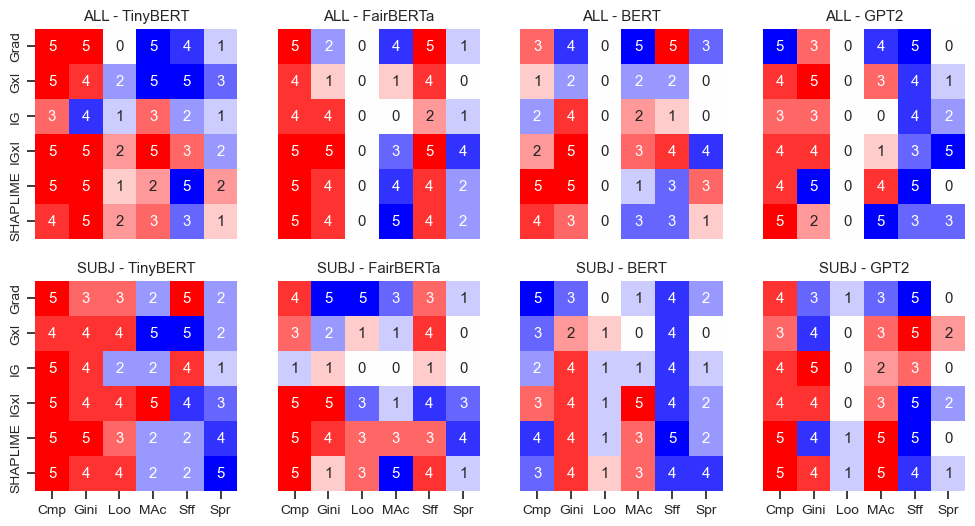

In [286]:
df["heatmap_count"] = df.apply(lambda x: -x["count"] if x["d_mean"] > 0 else x["count"], axis=1)

# f, ax = plt.subplots(figsize=(2, 2))

fig, ax = plt.subplots(ncols=4, nrows=2, figsize=(12,6))

heatmap_model_names = ["TinyBERT", "FairBERTa", "BERT", "GPT2"]


for i, dataset in enumerate(["ALL", "SUBJ"]):
    for j, model in enumerate(heatmap_model_names):
        filtered = df[df["dataset"] == dataset][df["model"] == model][df["n_epochs"] == 50]
        sns.heatmap(
            data=filtered.pivot(
                index="explainer", columns="metric", values="heatmap_count",
            ),
            cmap="bwr",
            cbar=False,
            annot=filtered.pivot(
                index="explainer", columns="metric", values="count",
            ),
            linewidths=0,
            ax=ax[i][j],
            yticklabels=j==0,
            xticklabels=i==1,
        ).set(title=f'{dataset} - {model}', xlabel=None, ylabel=None)

In [279]:
def ff(f):
    return ("%.2f" % f).replace("-0","-").lstrip("0")

def format_cell(x):
    text = f'({x["count"]}) {ff(x["d_mean"])}±{ff(x["d_std"])}'
    if abs(x["d_mean"]) >= 0.2:
        return f"\\textbf{{{text}}}"
    return text


df["val_str"] = df.apply(format_cell, axis=1) # format float printing
df["val_str"] = df["val_str"].replace("(0) nan±nan", "(0) NA")

In [280]:
all_results = df.copy()
all_results = all_results[all_results["n_epochs"] == 50]
all_results.drop(columns=["count", "d_mean", "d_std", "heatmap_count", "n_epochs"], inplace=True)
to_print = all_results.pivot_table(columns=["metric"], values=["val_str"], index=["dataset", "model", "explainer"], aggfunc=[lambda x: x])

In [281]:
cols = to_print.columns.tolist()
reordered = [cols[0], cols[2], cols[3], cols[4], cols[1], cols[5]]
to_print = to_print[reordered]

In [282]:
print(to_print.to_latex())

\begin{tabular}{lllllllll}
\toprule
 &  &  & \multicolumn{6}{r}{<lambda>} \\
 &  &  & \multicolumn{6}{r}{val_str} \\
 &  & metric & Cmp & Loo & MAc & Sff & Gini & Spr \\
dataset & model & explainer &  &  &  &  &  &  \\
\midrule
\multirow[t]{24}{*}{ALL} & \multirow[t]{6}{*}{BERT} & Grad & \textbf{(3) -.81±2.62} & (0) NA & (5) .12±.41 & \textbf{(5) -.24±.15} & (4) .03±.60 & (3) .08±.17 \\
 &  & GxI & (1) -.05±.00 & (0) NA & (2) .10±.00 & (2) .01±.88 & (2) .05±.38 & (0) NA \\
 &  & IG & (2) .11±.48 & (0) NA & (2) -.08±.00 & \textbf{(1) -.83±.00} & (4) -.15±.37 & (0) NA \\
 &  & IGxI & \textbf{(2) -.28±1.17} & (0) NA & \textbf{(3) -.47±.23} & (4) -.11±.10 & \textbf{(5) -.27±.91} & \textbf{(4) .38±.15} \\
 &  & LIME & \textbf{(5) -.52±1.20} & (0) NA & \textbf{(1) .51±.00} & (3) .08±.13 & \textbf{(5) -.57±1.10} & (3) -.09±.13 \\
 &  & SHAP & \textbf{(4) -.44±1.36} & (0) NA & \textbf{(3) .30±.22} & (3) .15±.28 & \textbf{(3) -.28±1.01} & \textbf{(1) -.35±.00} \\
\cline{2-9}
 & \multirow[t]{6}{

## box plot with aggregated scores

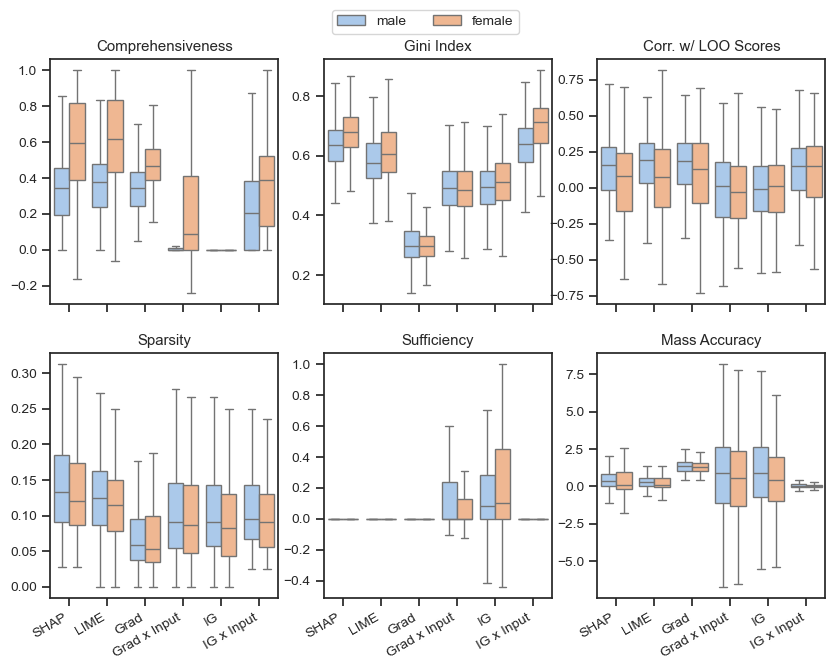

In [236]:
sns.set_theme(style="ticks", palette="pastel")
sns.set_context("notebook", font_scale=0.9)

metrics = [
    "aopc_compr",
    "aopc_suff",
    "taucorr_loo",
    "sparsity",
    "gini_index",
    "mass_acc",
]

metric_labels = {
    "aopc_compr": "Comprehensiveness",
    "aopc_suff": "Sufficiency",
    "taucorr_loo": "Corr. w/ LOO Scores",
    "sparsity": "Sparsity",
    "gini_index": "Gini Index",
    "mass_acc": "Mass Accuracy",
}

exp_labels = [
    "SHAP",
    "LIME",
    "Grad",
    "Grad x Input",
    "IG",
    "IG x Input",
]

# Create subplots
r = 10
fig, axes = plt.subplots(2, 3, figsize=(r,0.7*r))

# Plot the first metric
for i, metric in enumerate(metrics):
    a = axes[i % 2][i % 3]
    sns.boxplot(
        x="explainer",
        y="score",
        hue="gender",
        data=results[results["metric"] == metric][results["score"] < 15][results["score"] > -15],
        ax=a,
        showfliers=False,
        # legend=False,
    )
    a.set_title(metric_labels[metric])
    a.set_ylabel(None)
    a.set_xlabel(None)
    a.get_legend().remove()


    handles, labels = a.get_legend_handles_labels()
    # fig.legend(handles, labels, loc='upper center', ncol=2)
plt.legend(loc='upper center', bbox_to_anchor=(0.5,0.96), ncol=2, bbox_transform=fig.transFigure)


for ax in axes[0]:
    ax.set_xticklabels([])
    ax.set_xlabel(None)
for ax in axes[1]:
    ax.set_xticklabels(exp_labels, rotation=30, ha="right")

# plt.savefig('figures/fairberta_all.png', bbox_inches="tight")
plt.show()
